In [52]:
import os

import matplotlib.pyplot as plt
import numpy as np
import gempy as gp
import matplotlib.pyplot as plt
import pandas as pd
import gempy_viewer as gpv
import HelperMethods as helper

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

path_to_data = r"C:\Users\mrcon\OneDrive\Data B\School\GP2\Internship\Mineye\GIS\Tharsis\Output\formationinputpoints.csv"
path_to_orientations = r"C:\Users\mrcon\OneDrive\Data B\School\GP2\Internship\Mineye\GIS\Tharsis\Output\orientations.csv"
path_to_topography = r"C:\Users\mrcon\OneDrive\Data B\School\GP2\Internship\Mineye\GIS\Tharsis\Output\topo.tif"
path_to_topography_cleaned = r"C:\Users\mrcon\OneDrive\Data B\School\GP2\Internship\Mineye\GIS\Tharsis\Output\topo_cleaned.tif"

In [53]:
points_df = pd.read_csv(path_to_data, encoding='latin1', engine='python')
sampled_points_df       = sampling(points_df,plotting=False)
sampled_points_df = sampled_points_df[sampled_points_df['formation'].isin(['Tournaisian Plutonites', 'Upper Carboniferous Volcanics'])].reset_index(drop=True)

Formation: Upper Devonian Siliciclastics, Points: 18, Spacing: 2500.00
Formation: Visean Shales, Points: 16, Spacing: 2357.02
Formation: Tournaisian Plutonites, Points: 296, Spacing: 10137.94
Formation: Upper Carboniferous Volcanics, Points: 45, Spacing: 3952.85
Formation: Mid Carboniferous Shales, Points: 13, Spacing: 2124.59
-------------------
Formation: Upper Devonian Siliciclastics, Points left: 3
Formation: Visean Shales, Points left: 3
Formation: Tournaisian Plutonites, Points left: 5
Formation: Upper Carboniferous Volcanics, Points left: 6
Formation: Mid Carboniferous Shales, Points left: 2


In [54]:
orientations_df = pd.read_csv(path_to_orientations, encoding='latin1', engine='python')
orientations_df = orientations_df[orientations_df['formation'].isin(['Tournaisian Plutonites', 'Upper Carboniferous Volcanics'])].reset_index(drop=True)

In [55]:
# Add volcanic formation orientations around the blob
orange_one_orientations = [
    {'X': -703766, 'Y': 4548057, 'Z': 393, 'azimuth': 8 , 'dip': 80, 'polarity': 1, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':503 },
    {'X': -702385, 'Y': 4548338, 'Z': 339, 'azimuth': 17, 'dip': 80, 'polarity': 1, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':459 },
    {'X': -701112, 'Y': 4548706, 'Z': 372, 'azimuth': 33, 'dip': 80, 'polarity': 1, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':462 },
    {'X': -699803, 'Y': 4548937, 'Z': 304, 'azimuth': 15, 'dip': 80, 'polarity': 1, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':465 },
]

# Add inner points in volcanic formations
orange_one_points = [
    {'X': -704388, 'Y': 4548761, 'Z': 424, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':1 },
    {'X': -702784, 'Y': 4548667, 'Z': 417, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':2 },
    {'X': -701587, 'Y': 4548986, 'Z': 415, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':3 },
    {'X': -700196, 'Y': 4549062, 'Z': 368, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':4 },
]

orange_two_orientations = [
    {'X': -702240, 'Y': 4530674, 'Z': 339, 'azimuth':  178, 'dip': 80, 'polarity': 1, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':204},
    {'X': -700747, 'Y': 4530651, 'Z': 351, 'azimuth':  175, 'dip': 80, 'polarity': 1, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':201},
    {'X': -698793, 'Y': 4530772, 'Z': 392, 'azimuth':  152, 'dip': 80, 'polarity': 1, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':197},
    {'X': -696319, 'Y': 4531002, 'Z': 265, 'azimuth':  177, 'dip': 80, 'polarity': 1, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':192},
    {'X': -694922, 'Y': 4530496, 'Z': 232, 'azimuth':  360-20,  'dip': 80, 'polarity': 1, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':496},
    {'X': -696661, 'Y': 4529687, 'Z': 268, 'azimuth':  360-29,  'dip': 80, 'polarity': 1, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':492},
    {'X': -698831, 'Y': 4528912, 'Z': 289, 'azimuth':  360-90,  'dip': 80, 'polarity': 1, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':499},
]

orange_two_points = [
    {'X': -705633, 'Y': 4529553, 'Z': 309, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':5 },
    {'X': -703786, 'Y': 4530306, 'Z': 372, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':6 },
    {'X': -701928, 'Y': 4529213, 'Z': 299, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':7 },
    {'X': -699932, 'Y': 4530083, 'Z': 399, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':8 },
    {'X': -697469, 'Y': 4530115, 'Z': 337, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':9 },
    {'X': -695144, 'Y': 4530816, 'Z': 254, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':10 },
]

purple_one_orientations = [
    {'X': -704875, 'Y': 4547579, 'Z': 421, 'azimuth': 360-130, 'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 239},
    {'X': -704083, 'Y': 4546109, 'Z': 456, 'azimuth': 360-82 , 'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 243},
    # {'X': -705344, 'Y': 4545762, 'Z': 458, 'azimuth': 360-8  , 'dip': 80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 246},
    # {'X': -705294, 'Y': 4545407, 'Z': 417, 'azimuth': 360-169, 'dip': 80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 247},
    {'X': -703527, 'Y': 4545376, 'Z': 399, 'azimuth': 155,     'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 250},
    {'X': -702201, 'Y': 4545068, 'Z': 373, 'azimuth': 360-170, 'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 253},
    {'X': -702590, 'Y': 4543987, 'Z': 355, 'azimuth': 360-120, 'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 256},
    {'X': -701976, 'Y': 4542406, 'Z': 371, 'azimuth': 174,     'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 260},
    {'X': -699648, 'Y': 4544262, 'Z': 271, 'azimuth': 180-175, 'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 118},
    {'X': -695279, 'Y': 4543351, 'Z': 215, 'azimuth': 165,     'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 472},
    {'X': -692429, 'Y': 4541732, 'Z': 219, 'azimuth': 360-130, 'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 280},
    {'X': -688958, 'Y': 4540604, 'Z': 287, 'azimuth': 180,     'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 288},
    # {'X': -686600, 'Y': 4540323, 'Z': 357, 'azimuth': 360-78,'dip': 80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 295},
    {'X': -687674, 'Y': 4537940, 'Z': 317, 'azimuth': 360-28,  'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 304},
    {'X': -693327, 'Y': 4538250, 'Z': 320, 'azimuth': 360-20,  'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 140},
    {'X': -695596, 'Y': 4536354, 'Z': 311, 'azimuth': 360-125, 'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 147},
    {'X': -692417, 'Y': 4534570, 'Z': 344, 'azimuth': 360-125, 'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 156},
    # {'X': -692861, 'Y': 4532105, 'Z': 271, 'azimuth': 1,       'dip': 80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 66},
    # {'X': -695835, 'Y': 4533462, 'Z': 265, 'azimuth': 360-45,  'dip': 80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 61},
    # {'X': -698477, 'Y': 4533923, 'Z': 276, 'azimuth': 360-136, 'dip': 80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 180},
    # {'X': -695514, 'Y': 4532326, 'Z': 221, 'azimuth': 360-141, 'dip': 80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 56},
    # {'X': -693145, 'Y': 4531542, 'Z': 242, 'azimuth': 360-170, 'dip': 80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 50},
    {'X': -689300, 'Y': 4530782, 'Z': 329, 'azimuth': 360-148, 'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 42},
    {'X': -685612, 'Y': 4529745, 'Z': 350, 'azimuth': 360-167, 'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 34}
]

purple_one_points = [
    {'X': -706207, 'Y': 4546897, 'Z': 456, 'formation': 'Tournaisian Plutonites', 'formation_id': 11},
    {'X': -705998, 'Y': 4543672, 'Z': 353, 'formation': 'Tournaisian Plutonites', 'formation_id': 12},
    {'X': -703401, 'Y': 4542038, 'Z': 372, 'formation': 'Tournaisian Plutonites', 'formation_id': 13},
    {'X': -704532, 'Y': 4539023, 'Z': 304, 'formation': 'Tournaisian Plutonites', 'formation_id': 14},
    {'X': -699548, 'Y': 4541703, 'Z': 259, 'formation': 'Tournaisian Plutonites', 'formation_id': 15},
    {'X': -694019, 'Y': 4540824, 'Z': 379, 'formation': 'Tournaisian Plutonites', 'formation_id': 16},
    {'X': -688700, 'Y': 4539274, 'Z': 356, 'formation': 'Tournaisian Plutonites', 'formation_id': 17},
    {'X': -696951, 'Y': 4539107, 'Z': 452, 'formation': 'Tournaisian Plutonites', 'formation_id': 18},
    {'X': -697831, 'Y': 4535589, 'Z': 277, 'formation': 'Tournaisian Plutonites', 'formation_id': 19},
    {'X': -693684, 'Y': 4533536, 'Z': 317, 'formation': 'Tournaisian Plutonites', 'formation_id': 20},
    {'X': -703066, 'Y': 4532782, 'Z': 441, 'formation': 'Tournaisian Plutonites', 'formation_id': 21},
    {'X': -697956, 'Y': 4531861, 'Z': 370, 'formation': 'Tournaisian Plutonites', 'formation_id': 22},
    {'X': -692972, 'Y': 4529851, 'Z': 258, 'formation': 'Tournaisian Plutonites', 'formation_id': 23},
    {'X': -687611, 'Y': 4529599, 'Z': 278, 'formation': 'Tournaisian Plutonites', 'formation_id': 24},
]

purple_two_orientations = [
    {'X': -702086, 'Y': 4547617, 'Z': 305, 'azimuth': 57,      'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 456},
    {'X': -702050, 'Y': 4546343, 'Z': 388, 'azimuth': 90,      'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 450},
    {'X': -699276, 'Y': 4544496, 'Z': 301, 'azimuth': 1,       'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 440},
    {'X': -695971, 'Y': 4545025, 'Z': 228, 'azimuth': 17,      'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 432},
    {'X': -690920, 'Y': 4544663, 'Z': 270, 'azimuth': 2,       'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 365},
    {'X': -685649, 'Y': 4542597, 'Z': 305, 'azimuth': 10,      'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 352},
    {'X': -680364, 'Y': 4541714, 'Z': 311, 'azimuth': 35,      'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 325},
    {'X': -678590, 'Y': 4538774, 'Z': 303, 'azimuth': 136,     'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 410},
    {'X': -681204, 'Y': 4536335, 'Z': 298, 'azimuth': 116,     'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 402},
    {'X': -681857, 'Y': 4533030, 'Z': 154, 'azimuth': 77,      'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 394},
    {'X': -684465, 'Y': 4533598, 'Z': 139, 'azimuth': 360-175, 'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 428},
    {'X': -686429, 'Y': 4532274, 'Z': 141, 'azimuth': 105,     'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 85},
    {'X': -684187, 'Y': 4531110, 'Z': 220, 'azimuth': 32,      'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 91},
    {'X': -681889, 'Y': 4530922, 'Z': 195, 'azimuth': 0,       'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 96},
    {'X': -679527, 'Y': 4530507, 'Z': 127, 'azimuth': 360-21,  'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 389},
    # {'X': , 'Y': , 'Z': , 'azimuth': , 'dip': 80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': },
    # {'X': , 'Y': , 'Z': , 'azimuth': , 'dip': 80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': },
]

purple_two_points = [
    {'X': -699294, 'Y': 4546462, 'Z': 410, 'formation': 'Tournaisian Plutonites', 'formation_id': 25},
    {'X': -694394, 'Y': 4548221, 'Z': 281, 'formation': 'Tournaisian Plutonites', 'formation_id': 26},
    {'X': -690122, 'Y': 4545876, 'Z': 366, 'formation': 'Tournaisian Plutonites', 'formation_id': 27},
    {'X': -687986, 'Y': 4547928, 'Z': 453, 'formation': 'Tournaisian Plutonites', 'formation_id': 28},
    {'X': -687315, 'Y': 4544284, 'Z': 355, 'formation': 'Tournaisian Plutonites', 'formation_id': 29},
    {'X': -681578, 'Y': 4548305, 'Z': 431, 'formation': 'Tournaisian Plutonites', 'formation_id': 30},
    {'X': -679483, 'Y': 4544452, 'Z': 328, 'formation': 'Tournaisian Plutonites', 'formation_id': 31},
    {'X': -678562, 'Y': 4537541, 'Z': 321, 'formation': 'Tournaisian Plutonites', 'formation_id': 32},
    {'X': -679735, 'Y': 4533395, 'Z': 229, 'formation': 'Tournaisian Plutonites', 'formation_id': 33},
    {'X': -684258, 'Y': 4532306, 'Z': 180, 'formation': 'Tournaisian Plutonites', 'formation_id': 34},
]

# Convert list of dicts to DataFrame and concatenate
# orientations_df = pd.concat([orientations_df, pd.DataFrame(orange_one_orientations)], ignore_index=True)
# orientations_df = pd.concat([orientations_df, pd.DataFrame(orange_two_orientations)], ignore_index=True)
orientations_df = pd.concat([orientations_df, pd.DataFrame(purple_one_orientations)], ignore_index=True)
orientations_df = pd.concat([orientations_df, pd.DataFrame(purple_two_orientations)], ignore_index=True)

sampled_points_df = pd.concat([sampled_points_df, pd.DataFrame(orange_one_points)], ignore_index=True)
sampled_points_df = pd.concat([sampled_points_df, pd.DataFrame(orange_two_points)], ignore_index=True)
sampled_points_df = pd.concat([sampled_points_df, pd.DataFrame(purple_one_points)], ignore_index=True)
sampled_points_df = pd.concat([sampled_points_df, pd.DataFrame(purple_two_points)], ignore_index=True)

In [56]:
sampled_orientations_path = "sampled_orientationinputpoints8.csv"
orientations_df.to_csv(sampled_orientations_path, index=False)

In [57]:
# Save the sampled data to CSV files for GemPy
sampled_points_path = "sampled_formationinputpoints8.csv"
sampled_points_df.to_csv(sampled_points_path, index=False)

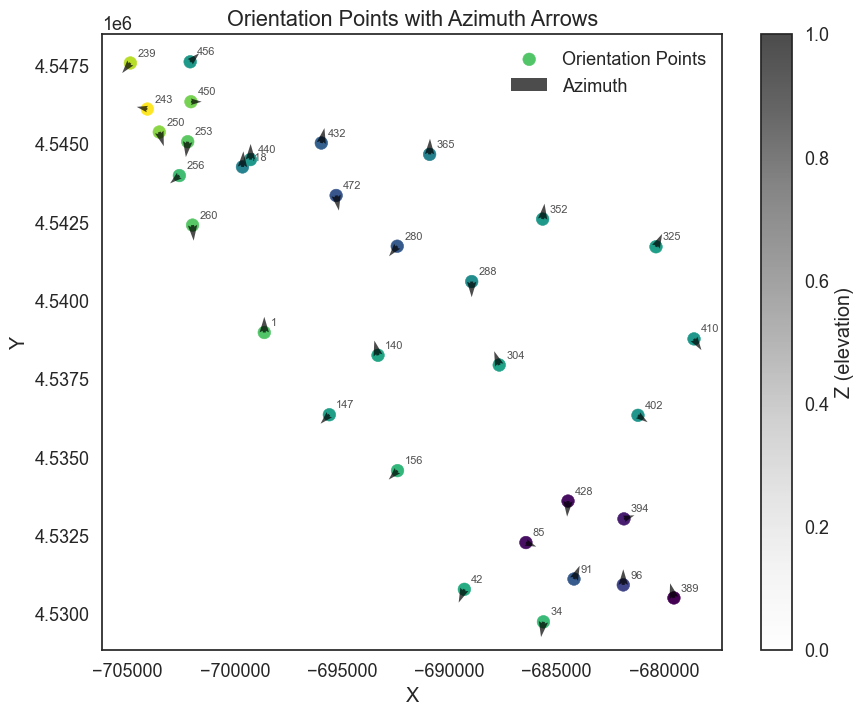

In [21]:
plt.figure(figsize=(10, 8))
plt.scatter(orientations_df['X'], orientations_df['Y'], c=orientations_df['Z'], cmap='viridis', label='Orientation Points')

# Add arrows for azimuth
length = 500  # arrow length in map units
azimuth_rad = np.deg2rad(orientations_df['azimuth'])
dx = length * np.sin(azimuth_rad)
dy = length * np.cos(azimuth_rad)

plt.quiver(
    orientations_df['X'], orientations_df['Y'],
    dx, dy,
    angles='xy', scale_units='xy', scale=1, color='black', width=0.005, alpha=0.7,
    label='Azimuth'
)
# Add text annotations for formation_id
for i, row in orientations_df.iterrows():
    plt.annotate(str(row['formation_id']), 
                (row['X'], row['Y']), 
                xytext=(5, 5), textcoords='offset points', 
                fontsize=8, alpha=0.8)

plt.colorbar(label='Z (elevation)')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Orientation Points with Azimuth Arrows')
plt.legend()

# Sampling code

In [3]:
def smart_sample(sub_df, min_spacing):
    coords = sub_df[['X', 'Y']].values
    tree = cKDTree(coords)
    sampled_indices = []
    mask = np.ones(len(coords), dtype=bool)

    for i in range(len(coords)):
        if mask[i]:
            sampled_indices.append(i)
            neighbors = tree.query_ball_point(coords[i], r=min_spacing)
            mask[neighbors] = False
            mask[i] = True

    return sub_df.iloc[sampled_indices]

In [4]:
def sampling(df,BASE_SPACING=2500,ALPHA=0.50,plotting=False):
    formation_counts = df['formation'].value_counts()
    median_count = formation_counts.median()

    sampled_points = []

    for formation in df['formation'].unique():
        sub_df = df[df['formation'] == formation]
        count = len(sub_df)

        # Penalize formations with more data
        factor = (count / median_count) ** ALPHA
        effective_spacing = BASE_SPACING * factor

        print(f"Formation: {formation}, Points: {count}, Spacing: {effective_spacing:.2f}")

        sampled_df = smart_sample(sub_df, effective_spacing)
        sampled_points.append(sampled_df)

        if plotting == True:
            # Plot
            fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
            x_min, x_max = df['X'].min(), df['X'].max()
            y_min, y_max = df['Y'].min(), df['Y'].max()

            sc1 = axes[0].scatter(sub_df['X'], sub_df['Y'], c=sub_df['Z'], cmap='viridis', s=10)
            axes[0].set_title(f"Original: {formation}")
            axes[0].set_xlim(x_min, x_max)
            axes[0].set_ylim(y_min, y_max)
            axes[0].set_aspect('equal')
            plt.colorbar(sc1, ax=axes[0], label='Z')

            sc2 = axes[1].scatter(sampled_df['X'], sampled_df['Y'], c=sampled_df['Z'], cmap='viridis', s=10)
            axes[1].set_title(f"Sampled: {formation}")
            axes[1].set_xlim(x_min, x_max)
            axes[1].set_ylim(y_min, y_max)
            axes[1].set_aspect('equal')
            plt.colorbar(sc2, ax=axes[1], label='Z')

            for ax in axes:
                ax.set_xlabel('X')
                ax.set_ylabel('Y')

            plt.tight_layout()
            plt.show()

    # Combine all sampled
    sampled_df_all = pd.concat(sampled_points, ignore_index=True)

    print('-------------------')
    for formation in sampled_df_all['formation'].unique():
        sub_df = sampled_df_all[sampled_df_all['formation'] == formation]
        count = len(sub_df)
        print(f"Formation: {formation}, Points left: {count}")

    return sampled_df_all

In [120]:
sampled_points_df       = sampling(points_df,plotting=False,BASE_SPACING=500, ALPHA=1.0)

Formation: Upper Devonian Siliciclastics, Points: 18, Spacing: 500.00
Formation: Visean Shales, Points: 16, Spacing: 444.44
Formation: Tournaisian Plutonites, Points: 296, Spacing: 8222.22
Formation: Upper Carboniferous Volcanics, Points: 45, Spacing: 1250.00
Formation: Mid Carboniferous Shales, Points: 13, Spacing: 361.11
-------------------
Formation: Upper Devonian Siliciclastics, Points left: 11
Formation: Visean Shales, Points left: 14
Formation: Tournaisian Plutonites, Points left: 7
Formation: Upper Carboniferous Volcanics, Points left: 17
Formation: Mid Carboniferous Shales, Points left: 11


In [ ]:
sampled_orientations_df = sampling(orientations_df, BASE_SPACING=5500, ALPHA=1.90)

Formation: Upper Devonian Siliciclastics, Points: 18, Spacing: 2500.00
Formation: Visean Shales, Points: 16, Spacing: 2357.02
Formation: Tournaisian Plutonites, Points: 296, Spacing: 10137.94
Formation: Upper Carboniferous Volcanics, Points: 45, Spacing: 3952.85
Formation: Mid Carboniferous Shales, Points: 13, Spacing: 2124.59
Formation: Upper Carboniferous Volcanics, Points: 1, Spacing: 5500.00
Formation: Upper Devonian Siliciclastics, Points: 3, Spacing: 44349.94
Formation: Tournaisian Plutonites, Points: 1, Spacing: 5500.00
Formation: Mid Carboniferous Shales, Points: 1, Spacing: 5500.00
